# PyTorch Workflow

1. Data (Prepare & Load)
2. Build Model
3. Fitting the model to data (Training)
4. Making Predictions and Evaluating a model (Inference)
5. Save & Load Model

In [1]:
import torch
from torch import nn # contains all PyTorch building blocks for graphs (computational graphs / NNs)
import matplotlib.pyplot as plt

## 1. Data (Preparing & Loading)

Data can be almost anything
- Excel
- Database
- Images
- Videos
- Audio
- DNA
- Text

ML is a game of two parts
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation

Let's create some *known* data using the linear regression formula ($y = ax + b$).

We'll use a linear regression formula to make a straight line with known **parameters**.

In [2]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### Splitting Data into Training & Test Sets

Usually there are three sets of data:
- Training Set: The model learns from this data. **Used always**.
- Validation Set: The model gets tuned (HyperParameter Tuning) on this data. **Often Used but not always**.
- Testing Set: The model gets evaluated on this data to test what it has learned. **Use always**.

In [4]:
# Create a train/test split
train_split = int(0.8 * len(X)) # 80% of X
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

### Visualize the data

In [6]:
def plot_predicions(train_data=X_train, 
                    train_labels=y_train, 
                    test_data=X_test, 
                    test_labels=y_test,
                   predictions=None):
    """
    Plots Training Data, Test Data & compares Predictions
    """
    plt.figure(figsize=(10, 7))

    # Plotting training data in blue
    plt.scatter(train_data, train_labels, c='b', marker='.', label="Training Data")

    # Plotting test data in green
    plt.scatter(test_data, test_labels, c='g', marker='o', label="Testing Data")

    if predictions is not None:
        # Plot Predictions in red
        plt.scatter(test_data, predictions, c='r', marker="x", label="Predictions")

    plt.legend(prop={"size": 14})

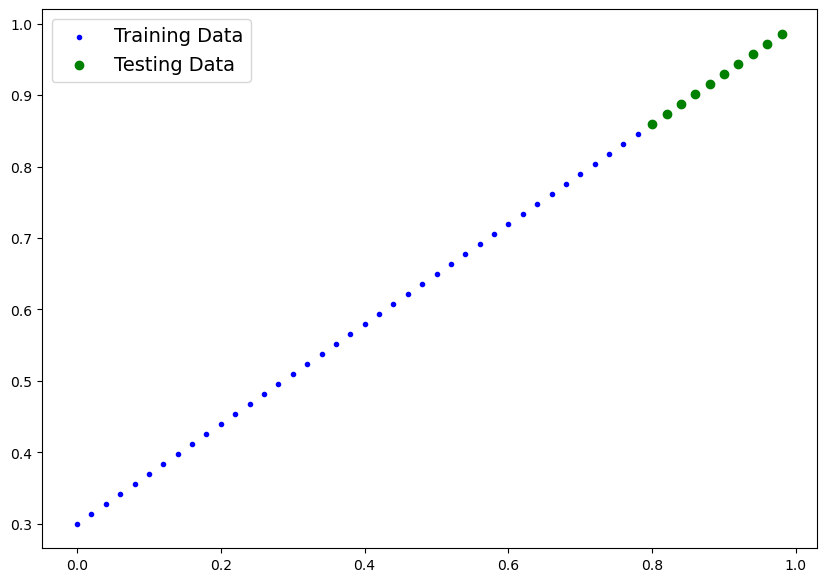

In [7]:
plot_predicions()

## 2. Build PyTorch Model

What the model does?
- Start with random values (weight & bias)
- Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias we used to create the data)

How it happens?
- Gradient Descent
- Backpropagation

In [8]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # Almost everything in PyTorch inherits nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input data
        return self.weights * x + self.bias # Linear Regression Formula

### PyTorch model building essentials

- `torch.nn`: contains all the building blocks for computational graphs (a NN can be considered a Computational Graph)
- `torch.nn.Parameter`: what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
- `torch.nn.Module`: The base class for all NN modules, if you subclass it, you should overwrite `forward()`
- `torch.optim`: This is where the optimizers in PyTorch live, they will help with gradient descent.
- `torch.nn.Module.forward`: All nn.Module subclasses require you to overwrite `forward()`, this method defines what happens in the forward computation.

### Checking the content of our PyTorch Model

We can check the parameters in a model using `.parameters()`

In [9]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model
model_0 = LinearRegressionModel()

model_0

LinearRegressionModel()

In [10]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# List names parameters
dict(model_0.state_dict())

{'weights': tensor([0.3367]), 'bias': tensor([0.1288])}

### Making predictions using torch.inference_mode()

To check the models current predicting capability, let's check how well it predicts `y_test` based on `X_test`

When we pass data through the model it's going to run through the `forward()` method

In [12]:
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

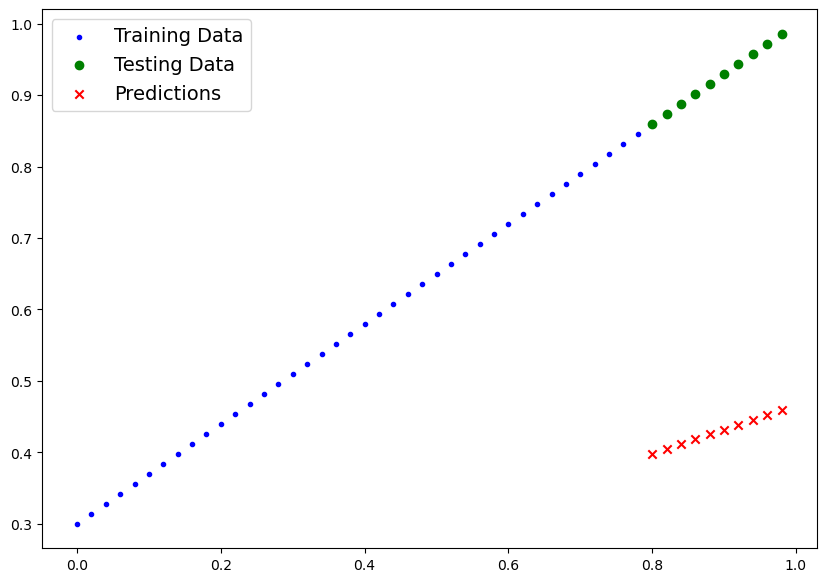

In [13]:
plot_predicions(predictions=y_preds)

## 3. Training the Model

Idea of training is for a model to move from some unknown parameters to some known parameters.

Or from a poor representation to a better representation of data.

How poor/wrong a model's predictions are is measured with the help of Loss Functions.

Loss Functions are also referred to as Cost Function or Criterion.


Things needed for training:
- **Loss Function** is a function to measure a how wrong a model's predictions are compared to the ideal predictions. Lower is Better.
- **Optimizer** takes into account the loss of a model and adjusts the model's parameters to improve/lower the loss function. Within the optimizer there are a set of parameters that need to be set:

  - `params`: The parameteres we need to optimize
  - `lr`: The learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes)

For PyTorch we need:
- A Training Loop
- A Testing Loop

In [14]:
# Setup a Loss Function
loss_fn = nn.L1Loss()

# Setup Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [15]:
loss_fn

L1Loss()

In [16]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [17]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

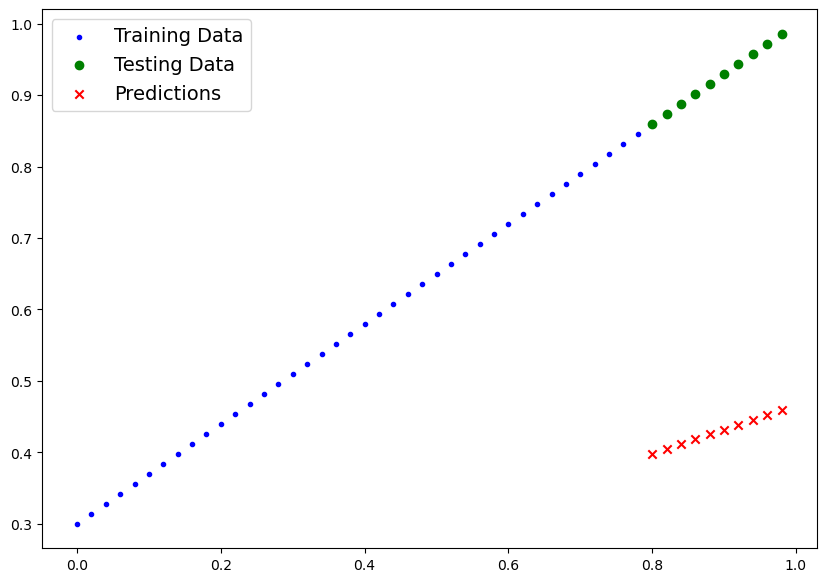

In [18]:
with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predicions(predictions=y_preds)

### Building a training loop (and a testing loop) in PyTorch

A Couple of things we need in a training loop:

0. Loop through the data and do the following:
1. Forward pass / Feed-Forward / Forward Propagartion (move the data through the models `forward()` functions) to make predictions
2. Calculate the loss (compare Forward Pass prediction to ground-truth labels)
3. Optimizer zero grad. By default, the changes that optimizer will make, accumulate through the loop, So it needs to be cleared/zeroed.
4. Loss backward (Backpropagation) - move backwards through the network to calculate the gradients of each of the parameters of the model with respect to the loss.
5. Optimizer step (Gradient Descent) - use the optimizer to adjust the model parameters to try and improve the loss.

In [19]:
# Training
# An epoch is one loop throug the data
epochs = 200

# Tracking
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()

    # 1. Feed-Forward
    y_pred = model_0(X_train)

    # 2. Calculate Loss
    loss = loss_fn(y_pred, y_train)
    
    # 3. Optimizer Zero Grad
    optimizer.zero_grad()
    
    # 4. Backpropagration
    loss.backward()

    # 5. Gradient Descent
    optimizer.step()


    ### Testing
    model_0.eval() # turns off certain settings in the model not needed for testing & inference
    with torch.inference_mode(): # turns off gradient tracking & a few more things that aren't required for testing & inference
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch: {epoch} | Loss: {loss.item()} | Test Loss: {test_loss.item()}")
        print(f"\tParameters: {model_0.state_dict()}")

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
	Parameters: OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
	Parameters: OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
	Parameters: OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
	Parameters: OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
	Parameters: OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
	Parameters: OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])
Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.0888663

In [20]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.6990], requires_grad=True),
 Parameter containing:
 tensor([0.3093], requires_grad=True)]

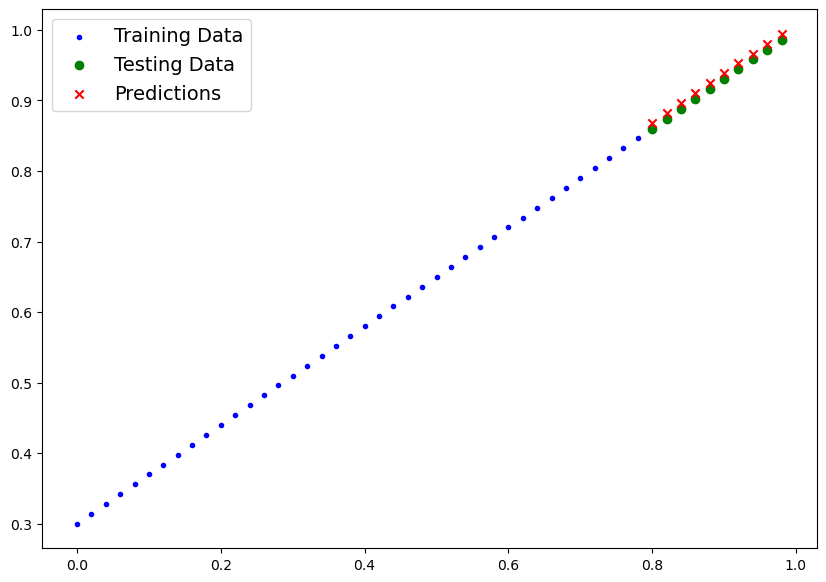

In [21]:
with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predicions(predictions=y_preds)

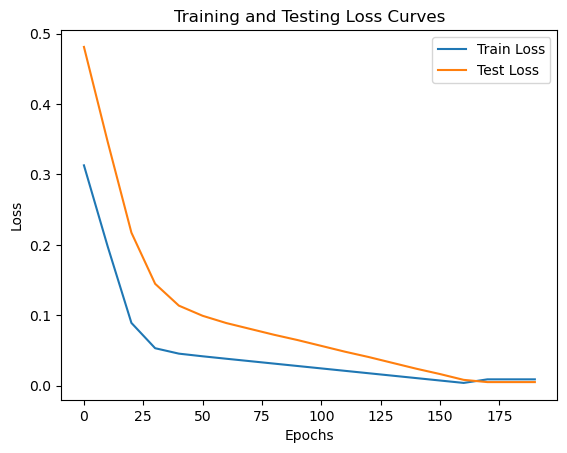

In [22]:
plt.plot(epoch_count, loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and Testing Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

## 5. Saving a model in PyTorch

There are three methods for loading & saving models:

- `torch.save()`: saves a PyTorch object in python pickle format
- `torch.load()`: allows loading a saved PyTorch object
- `torch.nn.Module.load_state_dict()`: allows loading a model's saved state dictionary.

In [34]:
# save the weights (Recommended method)
from pathlib import Path

# 1. Create module directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save state_dict
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

print(f"Model Saved to: {MODEL_SAVE_PATH}")

Model Saved to: models\01_pytorch_workflow_model_0.pt


In [35]:
# Loading the weights [For doing so we need to create a model of compatible type & then load the state into it]
model_load = LinearRegressionModel()
model_load.state_dict()

OrderedDict([('weights', tensor([-1.1229])), ('bias', tensor([-0.1863]))])

In [36]:
model_load.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))

<All keys matched successfully>

In [37]:
model_load.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [38]:
# Save the entire model
# save the weights (Recommended method)
from pathlib import Path

# 1. Create module directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create a model save path
MODEL_NAME = "01_pytorch_workflow_model_0_entire_model.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save state_dict
torch.save(model_0, MODEL_SAVE_PATH)

print(f"Model Saved to: {MODEL_SAVE_PATH}")

Model Saved to: models\01_pytorch_workflow_model_0_entire_model.pt


In [39]:
model_load_2 = torch.load(MODEL_SAVE_PATH, weights_only=False)
model_load_2.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

# Recap

In [133]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.5.0'

## Device Agnostic Code

Using GPU for faster computing if GPU isn't available then CPU will be used

In [134]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Data

In [177]:
weights = 0.54
bias = 0.9

X = torch.arange(0, 1, 0.015).unsqueeze(dim=1)
y = X * weights + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0150],
         [0.0300],
         [0.0450],
         [0.0600],
         [0.0750],
         [0.0900],
         [0.1050],
         [0.1200],
         [0.1350]]),
 tensor([[0.9000],
         [0.9081],
         [0.9162],
         [0.9243],
         [0.9324],
         [0.9405],
         [0.9486],
         [0.9567],
         [0.9648],
         [0.9729]]))

In [178]:
train_split = int(len(X) * 0.8)
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

X_train[:2], X_test[:2], y_train[:2], y_test[:2]

(tensor([[0.0000],
         [0.0150]]),
 tensor([[0.7950],
         [0.8100]]),
 tensor([[0.9000],
         [0.9081]]),
 tensor([[1.3293],
         [1.3374]]))

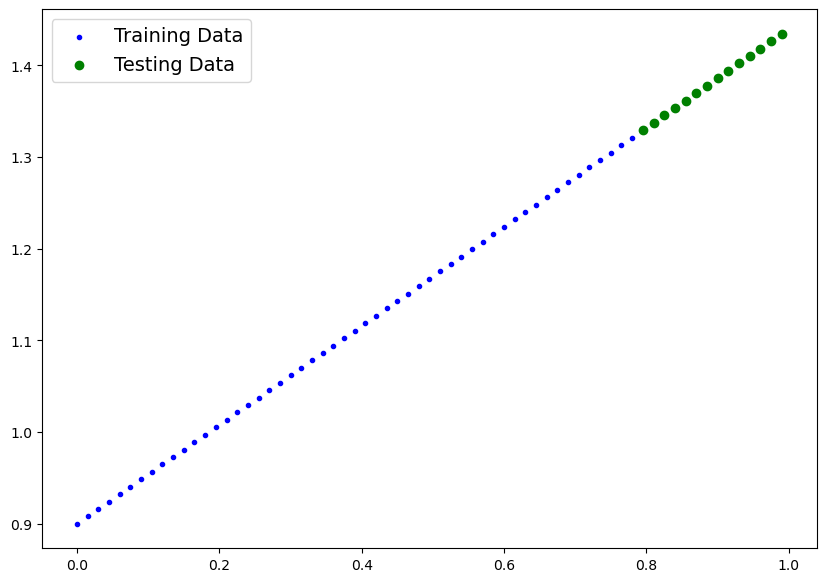

In [179]:
plot_predicions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test)

## 2. Building Model

In [180]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float64))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float64))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.weights + self.bias

In [181]:
my_model = LinearModel()
my_model, my_model.state_dict()

(LinearModel(),
 OrderedDict([('weights', tensor([-0.0499], dtype=torch.float64)),
              ('bias', tensor([0.5263], dtype=torch.float64))]))

## 3. Training the Model

### 3.1 Creating Optimizer & Loss Function

In [182]:
loss_fn = nn.L1Loss()
loss_fn

L1Loss()

In [183]:
optimizer = torch.optim.SGD(params=my_model.parameters(), lr=0.01)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### 3.2 Creating the Training Loop

In [184]:
epochs = 300

for epoch in range(epochs):
    my_model.train()

    preds = my_model(X_train)

    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 0.603725349396169
Epoch: 10 | Loss: 0.4885153492715516
Epoch: 20 | Loss: 0.3733053491469342
Epoch: 30 | Loss: 0.25809534902231684
Epoch: 40 | Loss: 0.14667526698427533
Epoch: 50 | Loss: 0.09296592303399229
Epoch: 60 | Loss: 0.07518335206626714
Epoch: 70 | Loss: 0.06845255293306712
Epoch: 80 | Loss: 0.0644689564915593
Epoch: 90 | Loss: 0.06095388229949691
Epoch: 100 | Loss: 0.05753455495548542
Epoch: 110 | Loss: 0.05412100078207422
Epoch: 120 | Loss: 0.050726231669979784
Epoch: 130 | Loss: 0.04733146255788537
Epoch: 140 | Loss: 0.04393669344579089
Epoch: 150 | Loss: 0.04054256475963979
Epoch: 160 | Loss: 0.037149399046681235
Epoch: 170 | Loss: 0.0337562333337227
Epoch: 180 | Loss: 0.03036306762076419
Epoch: 190 | Loss: 0.02696990190780563
Epoch: 200 | Loss: 0.023576736194847077
Epoch: 210 | Loss: 0.020183521122558386
Epoch: 220 | Loss: 0.01678875201046393
Epoch: 230 | Loss: 0.013393982898369447
Epoch: 240 | Loss: 0.009999213786274948
Epoch: 250 | Loss: 0.006604444674180

## 4. Testing & Inference

In [185]:
with torch.inference_mode():
    y_preds = my_model(X_test)

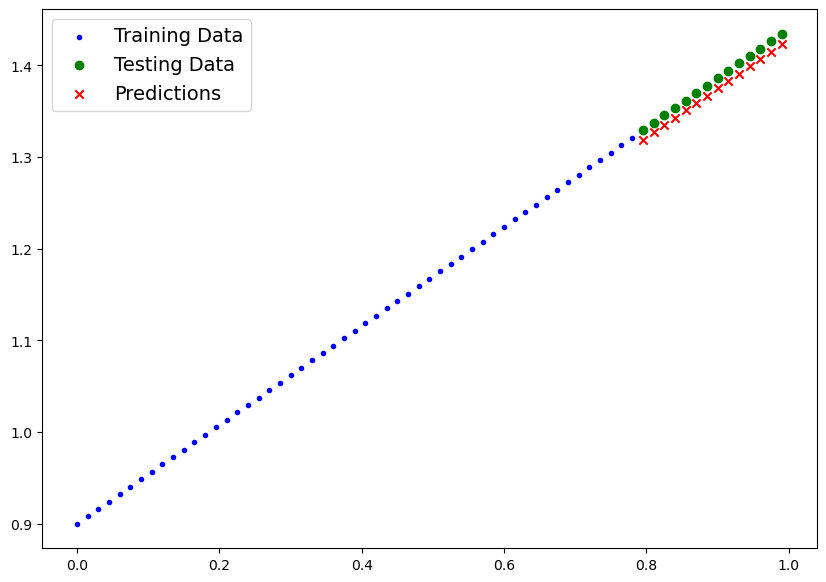

In [186]:
plot_predicions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=y_preds)

# Using nn.Linear for creating the model

It creates a linear layer that applies linear transformation to the input data

$ y = x A^T + b $

Linear layer is also known as: Linear transform, Probing Layer, Fully connected layer, dense layer

In [187]:
class LinearModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float64))
        # self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float64))
        # Using nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1, out_features=1) # here 1 & 1 come from X & y. For each data point one value of X maps to one value of y

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # return x * self.weights + self.bias
        return self.linear_layer(x)

In [188]:
mm = LinearModelV2()
mm

LinearModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [189]:
list(mm.parameters())

[Parameter containing:
 tensor([[0.0630]], requires_grad=True),
 Parameter containing:
 tensor([-0.6825], requires_grad=True)]

In [190]:
mm.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.0630]])),
             ('linear_layer.bias', tensor([-0.6825]))])

In [191]:
# Check the model current device
next(mm.parameters()).device

device(type='cpu')

In [192]:
# Set to GPU
mm.to(device)
next(mm.parameters()).device

device(type='cuda', index=0)

In [193]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(mm.parameters(), lr=0.01)

loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [195]:
epochs = 300

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    mm.train()

    preds = mm(X_train)

    loss = loss_fn(preds, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 1.7685843706130981
Epoch: 10 | Loss: 1.653374433517456
Epoch: 20 | Loss: 1.5381646156311035
Epoch: 30 | Loss: 1.4229546785354614
Epoch: 40 | Loss: 1.3077446222305298
Epoch: 50 | Loss: 1.1925345659255981
Epoch: 60 | Loss: 1.077324628829956
Epoch: 70 | Loss: 0.9621147513389587
Epoch: 80 | Loss: 0.8469046950340271
Epoch: 90 | Loss: 0.7316946983337402
Epoch: 100 | Loss: 0.6164848208427429
Epoch: 110 | Loss: 0.5012748837471008
Epoch: 120 | Loss: 0.3860650360584259
Epoch: 130 | Loss: 0.2708551287651062
Epoch: 140 | Loss: 0.15564528107643127
Epoch: 150 | Loss: 0.040500350296497345
Epoch: 160 | Loss: 0.02135341987013817
Epoch: 170 | Loss: 0.01793034002184868
Epoch: 180 | Loss: 0.014537177979946136
Epoch: 190 | Loss: 0.011144021525979042
Epoch: 200 | Loss: 0.007750859018415213
Epoch: 210 | Loss: 0.004357705824077129
Epoch: 220 | Loss: 0.007076633628457785
Epoch: 230 | Loss: 0.007076633628457785
Epoch: 240 | Loss: 0.007076633628457785
Epoch: 250 | Loss: 0.007076633628457785
Epoc

In [196]:
with torch.inference_mode():
    y_preds = mm(X_test)

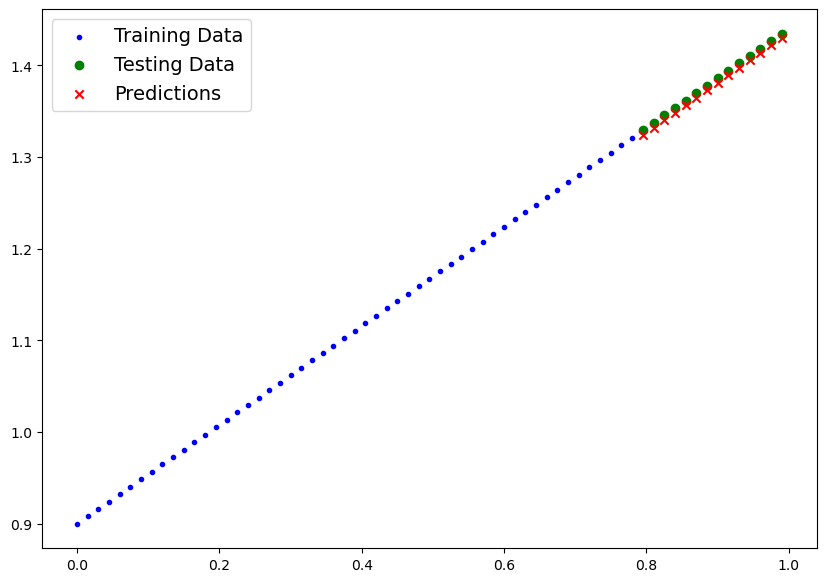

In [198]:
plot_predicions(train_data=X_train.cpu(), train_labels=y_train.cpu(), test_data=X_test.cpu(), test_labels=y_test.cpu(), predictions=y_preds.cpu())

In [199]:
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "001_recap_model.pt"
MODEL_PATH = MODELS_DIR / MODEL_NAME

torch.save(mm.state_dict(), MODEL_PATH)
print(f"Saved at: {MODEL_PATH}")

Saved at: models\001_recap_model.pt


In [207]:
mm_reload = LinearModelV2()
mm_reload.load_state_dict(torch.load(MODEL_PATH, weights_only=True, map_location=device))
mm_reload.to(device)

LinearModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [208]:
mm.state_dict(), mm_reload.state_dict()

(OrderedDict([('linear_layer.weight', tensor([[0.5448]], device='cuda:0')),
              ('linear_layer.bias', tensor([0.8910], device='cuda:0'))]),
 OrderedDict([('linear_layer.weight', tensor([[0.5448]], device='cuda:0')),
              ('linear_layer.bias', tensor([0.8910], device='cuda:0'))]))

In [209]:
next(mm.parameters()).device, next(mm_reload.parameters()).device

(device(type='cuda', index=0), device(type='cuda', index=0))